# Random Forest:

### Importação das Bibliotecas:

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Sistema de arquivos e manipulação de caminhos
import glob
import os

# Machine Learning - Pré-processamento e Modelo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Machine Learning - Métricas de Avaliação
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Salvar/Carregar modelo e outros artefatos
import joblib

# Ignorar avisos para manter o notebook limpo
import warnings
warnings.filterwarnings('ignore')

### 2. Carregamento e Concatenação dos Dados

#### Carregamos todos os arquivos CSV do dataset CICIDS2017.
##### O parâmetro `low_memory=False` ajuda a evitar erros de tipo de dado durante a leitura de arquivos grandes.

In [2]:
# Define o caminho para a pasta contendo os arquivos CSV
caminho = '../MachineLearningCSV/MachineLearningCVE/'
todos_os_arquivos = glob.glob(os.path.join(caminho, "*.csv"))

# Cria uma lista para armazenar cada DataFrame lido
lista_de_dfs = []
for arquivo in todos_os_arquivos:
    df = pd.read_csv(arquivo, low_memory=False)
    lista_de_dfs.append(df)

# Concatena todos os DataFrames da lista em um único DataFrame
dados = pd.concat(lista_de_dfs, axis=0, ignore_index=True)

print(f"Dataset carregado com {dados.shape[0]} linhas e {dados.shape[1]} colunas.")

Dataset carregado com 2830743 linhas e 79 colunas.


### 3. Limpeza e Pré-Processamento dos Dados

 Realizamos as seguintes ações:
 1. Padronizamos os nomes das colunas, removendo espaços em branco.
 2. Forçamos a conversão de todas as colunas para um tipo numérico, tratando erros que possam surgir.
 3. Substituímos valores infinitos (comuns em cálculos de rede) por 'NaN' (Not a Number).
 4. Removemos quaisquer linhas que ainda contenham valores ausentes ('NaN') após o tratamento.
 5. Separamos o DataFrame em 'X' (features) e 'y' (target).
 6. Codificamos a coluna alvo 'Label', que está em formato de texto, para um formato numérico que o modelo possa entender.

In [3]:
# 1. Remove espaços extras dos nomes das colunas
dados.columns = dados.columns.str.strip()

# 2. Converte colunas que são do tipo 'object' para numérico.
#    Valores que não podem ser convertidos se tornarão NaN (Not a Number).
#    A coluna 'Label' será tratada depois.
for col in dados.columns:
    if dados[col].dtype == 'object' and col != 'Label':
        dados[col] = pd.to_numeric(dados[col], errors='coerce')

# 3. Substitui valores infinitos (positivos e negativos) por NaN.
dados.replace([np.inf, -np.inf], np.nan, inplace=True)

# 4. Remove todas as linhas que contêm qualquer valor NaN.
dados.dropna(inplace=True)

# Garante que a coluna 'Label' não foi totalmente removida
if 'Label' not in dados.columns:
    raise ValueError("A coluna 'Label' foi removida durante a limpeza. Verifique a qualidade dos dados iniciais.")

# 5. Separa as features (X) do nosso alvo (y)
X = dados.drop('Label', axis=1)
y = dados['Label']

# 6. Codifica o alvo 'y' para formato numérico
label_encoder = LabelEncoder()
y_codificado = label_encoder.fit_transform(y)

print("Limpeza e pré-processamento concluídos.")
print(f"Distribuição das classes (após limpeza):\n{pd.Series(y_codificado).value_counts()}")

Limpeza e pré-processamento concluídos.
Distribuição das classes (após limpeza):
0     2271320
4      230124
10     158804
2      128025
3       10293
7        7935
11       5897
6        5796
5        5499
1        1956
12       1507
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [5]:
#  Verificação das Labels
# A variável 'y' foi criada na célula de limpeza e contém a coluna 'Label'.

print("Distribuição de todas as classes encontradas no dataset combinado:")
print(y.value_counts())

print("\nClasses únicas que o LabelEncoder aprendeu:")
print(label_encoder.classes_)

Distribuição de todas as classes encontradas no dataset combinado:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Classes únicas que o LabelEncoder aprendeu:
['BENIGN' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


### 4. Definição Manual de Features Realistas

 **O Problema (Data Leakage):** O dataset original contém features que são calculadas sobre o fluxo de rede completo (ex: `Flow Duration`).

Em um cenário real, nosso sistema (NDR) precisa tomar uma decisão de bloqueio ou alerta analisando apenas os **primeiros pacotes** de uma conexão.
Usar features que olham o fluxo completo resulta em modelos com performance irrealisticamente alta e sem valor prático.

 **A Solução:** Para simular um ambiente de produção e evitar o Data Leakage, selecionamos **manualmente** um subconjunto de features que podem ser realisticamente extraídas no início de uma conexão de rede.

In [6]:
# Lista de features que são consideradas realistas para detecção em tempo real.
# O modelo terá que inferir o protocolo a partir de outras features, como as flags TCP.
features_realistas = [
    'Destination Port',       # Porta de destino (ex: 80 para HTTP, 22 para SSH)
    'Fwd Packet Length Min',  # Tamanho mínimo do pacote de ida (proxy para o tamanho do 1º pacote)
    'Init_Win_bytes_forward', # Tamanho da janela TCP inicial de ida (do SYN)
    'Init_Win_bytes_backward',# Tamanho da janela TCP inicial de volta (do SYN/ACK)

    # Flags do cabeçalho TCP, cruciais para entender o estado da conexão
    'FIN Flag Count',
    'SYN Flag Count',
    'RST Flag Count',
    'PSH Flag Count',
    'ACK Flag Count',
    'URG Flag Count',
    'ECE Flag Count',

    # Outras flags que podem ser relevantes
    'Fwd PSH Flags',
    'Bwd PSH Flags',
    'Fwd URG Flags'
]

# Verifica se todas as features selecionadas realmente existem no DataFrame para evitar erros de digitação.
features_faltantes = [f for f in features_realistas if f not in X.columns]
if features_faltantes:
    raise ValueError(f"As seguintes features não foram encontradas no DataFrame: {features_faltantes}")

# Cria o novo DataFrame 'X' contendo apenas as features realistas
X_realista = X[features_realistas]

print("Seleção manual de features concluída.")
print(f"Número de features selecionadas: {X_realista.shape[1]}")
print("\nFeatures utilizadas no modelo:")
for feature in X_realista.columns:
    print(f"- {feature}")

Seleção manual de features concluída.
Número de features selecionadas: 14

Features utilizadas no modelo:
- Destination Port
- Fwd Packet Length Min
- Init_Win_bytes_forward
- Init_Win_bytes_backward
- FIN Flag Count
- SYN Flag Count
- RST Flag Count
- PSH Flag Count
- ACK Flag Count
- URG Flag Count
- ECE Flag Count
- Fwd PSH Flags
- Bwd PSH Flags
- Fwd URG Flags


### 5. Divisão dos Dados em Treino e Teste

 Agora que temos nosso conjunto de features final (`X_realista`), vamos dividi-lo.
 - 70% dos dados serão usados para treinar o modelo.
 - 30% dos dados serão reservados para testar a performance do modelo em dados que ele nunca viu.

 O parâmetro `stratify=y_codificado` é extremamente importante. Ele garante que a proporção
 de cada classe de ataque (DDoS, PortScan, etc.) seja a mesma tanto no conjunto de treino
 quanto no de teste.
 Isso evita que, por azar, uma classe de ataque rara acabe só no conjunto de teste e o modelo nunca aprenda a identificá-la.

In [7]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_realista,
    y_codificado,
    test_size=0.3,
    random_state=42,
    stratify=y_codificado
)

print("Divisão dos dados concluída.")
print(f"Shape do conjunto de treino (X_treino): {X_treino.shape}")
print(f"Shape do conjunto de teste (X_teste):   {X_teste.shape}")

Divisão dos dados concluída.
Shape do conjunto de treino (X_treino): (1979513, 14)
Shape do conjunto de teste (X_teste):   (848363, 14)


### 6. Treinamento do Modelo Random Forest

 Com os dados de treino preparados, finalmente podemos treinar nosso classificador.
 Usaremos o `RandomForestClassifier` por ser um modelo robusto e bom para benchmarks.
 - `n_estimators=100`: Usaremos 100 "árvores" na nossa floresta. É um bom ponto de partida.
 - `random_state=42`: Garante que o resultado seja sempre o mesmo se rodarmos o código de novo (reprodutibilidade).
 - `n_jobs=-1`: Utiliza todos os núcleos de processamento do seu computador para acelerar o treinamento.

In [8]:
print("Iniciando o treinamento do modelo Random Forest...")

# Instancia o classificador com os parâmetros definidos
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Treina o modelo usando os dados de treino
rf_model.fit(X_treino, y_treino)

print("Treinamento concluído.")

Iniciando o treinamento do modelo Random Forest...
Treinamento concluído.


### 7. Avaliação do Modelo

 Após o treinamento, é fundamental avaliar a performance do modelo em dados que ele nunca viu (o conjunto de teste).
 Utilizaremos as seguintes métricas:

 - **Relatório de Classificação (`classification_report`):** Fornece precisão, recall, F1-score e suporte para cada classe.
 - **F1-Score Ponderado (`f1_score` com `average='weighted'`):** Uma métrica que equilibra precisão e recall, ponderando pela quantidade de amostras em cada classe. É útil para datasets desbalanceados.
 - **Matriz de Confusão (`confusion_matrix`):** Uma tabela que mostra o número de previsões corretas e incorretas para cada classe, permitindo visualizar onde o modelo está errando.
 - **Curva ROC (Receiver Operating Characteristic) e AUC (Area Under the Curve):** Avalia a capacidade do modelo de distinguir entre as classes em diferentes limiares de classificação. Para problemas multiclasse, é comum plotar uma curva ROC "um contra o resto" para cada classe.

--- Relatório de Classificação ---
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.98      0.99    681396
                       Bot       0.98      0.72      0.83       587
                      DDoS       0.93      1.00      0.96     38408
             DoS GoldenEye       0.90      0.31      0.46      3088
                  DoS Hulk       0.95      1.00      0.98     69037
          DoS Slowhttptest       0.67      0.74      0.70      1650
             DoS slowloris       0.90      0.56      0.69      1739
               FTP-Patator       0.88      1.00      0.94      2380
                Heartbleed       1.00      1.00      1.00         3
              Infiltration       1.00      0.91      0.95        11
                  PortScan       0.83      1.00      0.91     47641
               SSH-Patator       1.00      1.00      1.00      1769
  Web Attack � Brute Force       0.85      0.13      0.22       452
Web Attack �

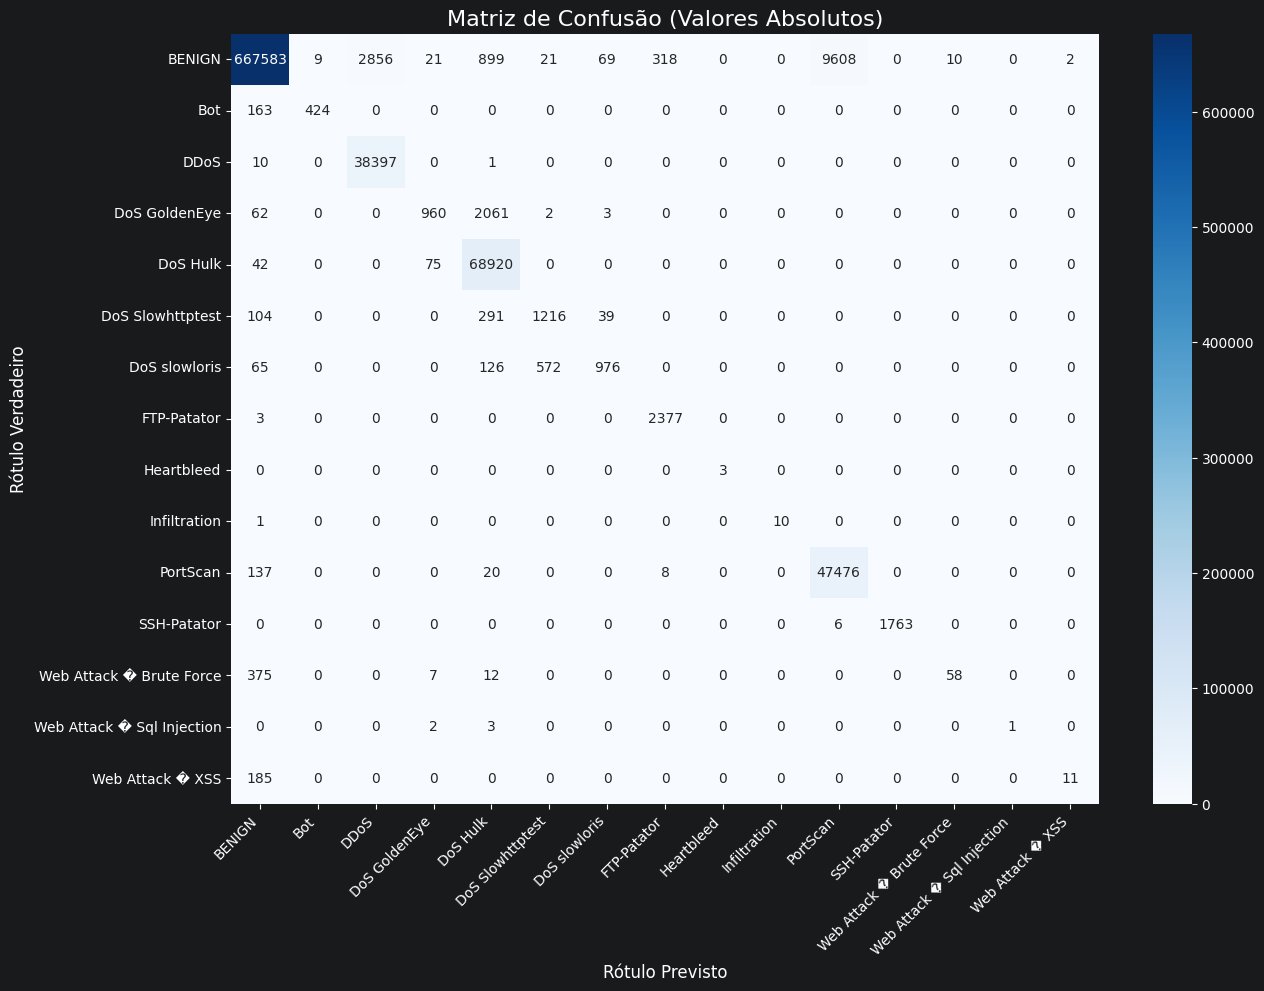

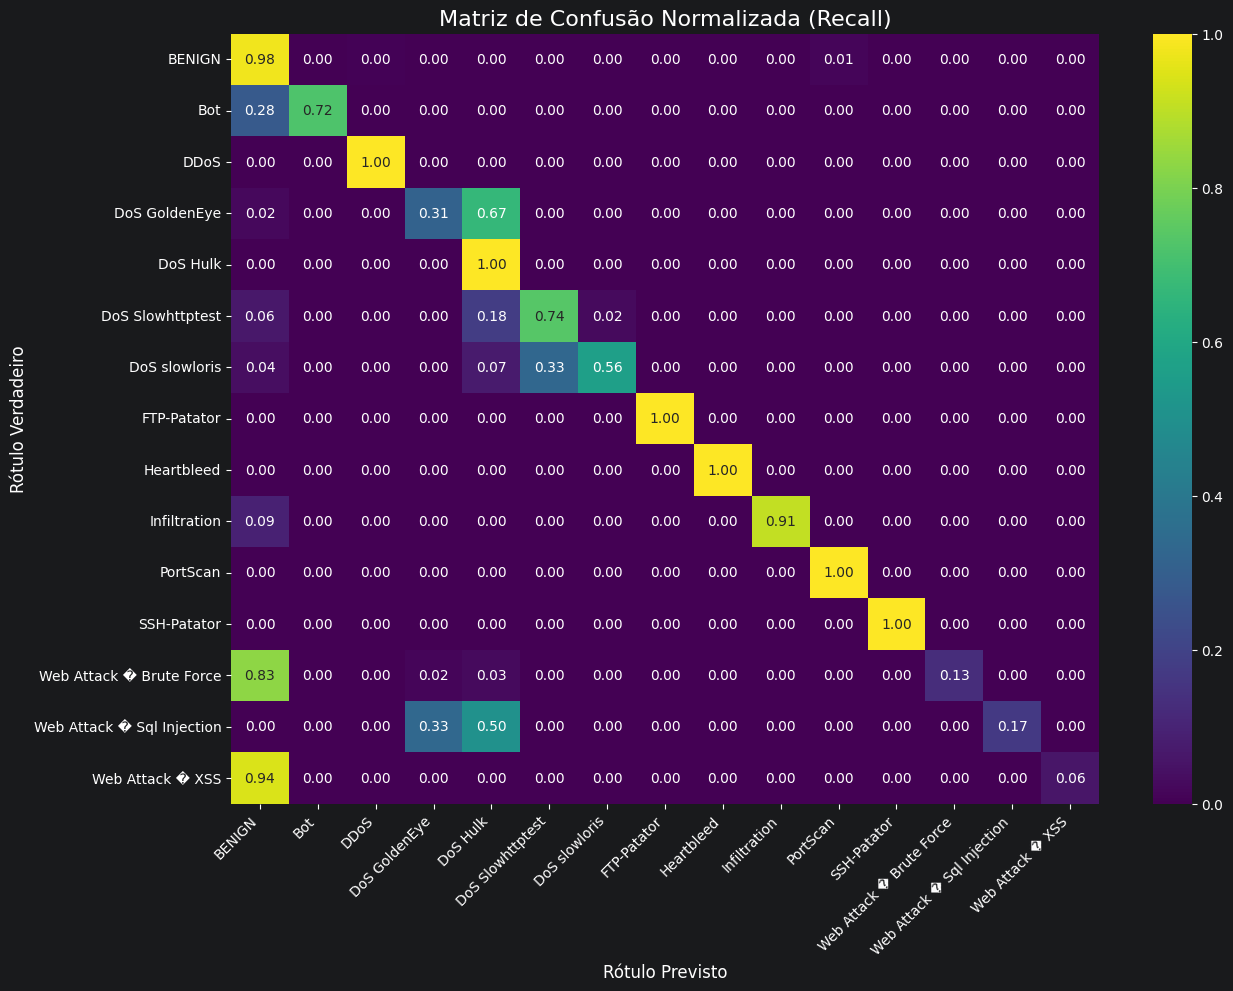

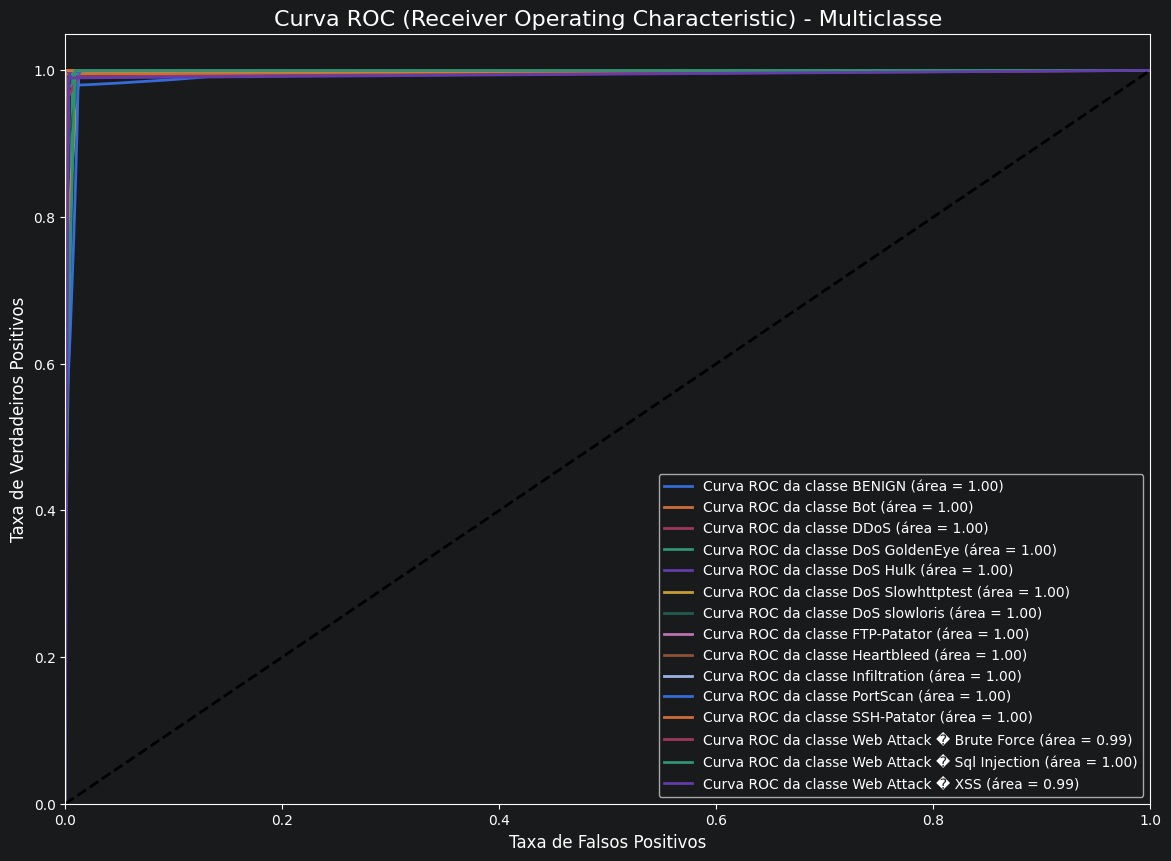

In [10]:
y_pred = rf_model.predict(X_teste)
y_pred_proba = rf_model.predict_proba(X_teste)

# --- Relatório de Classificação ---
print("--- Relatório de Classificação ---")
print(classification_report(y_teste, y_pred, target_names=label_encoder.classes_.astype(str)))

# --- Matriz de Confusão (Absoluta) ---
cm_abs = confusion_matrix(y_teste, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_.astype(str),
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão (Valores Absolutos)', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# --- Matriz de Confusão (Normalizada/Recall) ---
cm_norm = cm_abs.astype('float') / cm_abs.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=label_encoder.classes_.astype(str),
            yticklabels=label_encoder.classes_.astype(str))
plt.title('Matriz de Confusão Normalizada (Recall)', fontsize=16)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.xlabel('Rótulo Previsto', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


# --- Curva ROC (Um-contra-o-Resto) ---
from sklearn.preprocessing import label_binarize
y_teste_bin = label_binarize(y_teste, classes=np.arange(len(label_encoder.classes_)))
n_classes = y_teste_bin.shape[1]
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_teste_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(14, 10))
for i, class_name in enumerate(label_encoder.classes_):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Curva ROC da classe {class_name} (área = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12)
plt.title('Curva ROC (Receiver Operating Characteristic) - Multiclasse', fontsize=16)
plt.legend(loc="lower right")
plt.show()

### 8. Salvando o Modelo e os Artefatos

 Esta é a etapa final do notebook de pesquisa.
 Aqui, salvamos três artefatos essenciais em disco usando `joblib`,
 que é eficiente para objetos Python que contêm grandes arrays de dados (como nossos modelos).

 1. **O Modelo Treinado (`random_forest_model.joblib`):** O classificador que acabamos de treinar.
 2. **O Codificador de Rótulos (`label_encoder.joblib`):** Essencial para traduzir as previsões numéricas do modelo (ex: 0, 1, 2) de volta para seus nomes originais ('BENIGN', 'DDoS', 'PortScan').
 3. **A Lista de Features (`features_realistas.joblib`):** Garante que os próximos modelos e o sensor em produção (`extractor.py`) usarão exatamente as mesmas features que definimos aqui, mantendo a consistência.

In [11]:
# Pega o diretório atual do notebook e sobe um nível para a raiz do projeto.
try:
    project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
except:
    project_root = os.getcwd()

model_dir = os.path.join(project_root, 'models')

# Cria o diretório se ele não existir
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Diretório criado: {model_dir}")

# --- 1. Salva o modelo treinado ---
model_path = os.path.join(model_dir, 'random_forest_model.joblib')
joblib.dump(rf_model, model_path)
print(f"Modelo salvo em: {model_path}")

# --- 2. Salva o codificador de rótulos ---
encoder_path = os.path.join(model_dir, 'label_encoder.joblib')
joblib.dump(label_encoder, encoder_path)
print(f"Codificador de rótulos salvo em: {encoder_path}")

# --- 3. Salva a lista de features utilizadas ---
features_path = os.path.join(model_dir, 'features_realistas.joblib')
joblib.dump(X_realista.columns.tolist(), features_path)
print(f"Lista de features salva em: {features_path}")

# --- Verificação Final ---
print("\n--- Verificando arquivos salvos no diretório 'models' ---")
try:
    print(os.listdir(model_dir))
except Exception as e:
    print(f"Não foi possível listar os arquivos: {e}")

Modelo salvo em: /home/henrique/PycharmProjects/ndr-tcc/models/random_forest_model.joblib
Codificador de rótulos salvo em: /home/henrique/PycharmProjects/ndr-tcc/models/label_encoder.joblib
Lista de features salva em: /home/henrique/PycharmProjects/ndr-tcc/models/features_realistas.joblib

--- Verificando arquivos salvos no diretório 'models' ---
['label_encoder.joblib', 'random_forest_model.joblib', 'features_realistas.joblib', 'top_15_features.joblib']
